In [1]:

#Set project root variables
from pathlib import Path
import sqlite3
import pandas as pd

project_root = Path.cwd().parents[0]
db_path = project_root / "database" / "faers.db"

conn = sqlite3.connect(db_path)

In [2]:
#Checking for name variations of Metformin in the drug table to ensure we capture all relevant reports in our analysis.

Metformin_query = pd.read_sql_query("""

SELECT DISTINCT drugname
FROM drug
WHERE drugname LIKE '%METFORMIN%'
ORDER BY drugname;
        """,
        conn)

Metformin_query

,drugname
0,metformin 500 mg 24 hr tablet;
1,ALOGLIPTIN AND METFORMIN HYDROCHLORIDE
2,ALOGLIPTIN BENZOATE\METFORMIN HYDROCHLORIDE
3,ALOGLIPTIN-METFORMIN
4,ANAGLIPTIN/METFORMIN HYDROCHLORIDE COMBINED DRUG
...,...
248,metformin ER 500mg tablets
249,metformin XR
250,metformin XR 500 mg
251,metformin [METFORMIN]


In [3]:
#Counting how many values exist for each drug name variation to understand the distribution of reports across different Metformin formulations and combinations.

Metformin_query_report_numbers = pd.read_sql_query("""

SELECT DISTINCT drugname, COUNT(*) AS report_count
FROM drug
WHERE drugname LIKE '%METFORMIN%'
GROUP BY drugname
HAVING COUNT(*) >= 100
ORDER BY report_count DESC;
        """,
        conn)

Metformin_query_report_numbers

,drugname,report_count
0,METFORMIN,30824
1,METFORMIN HYDROCHLORIDE,12761
2,METFORMIN\SITAGLIPTIN,425
3,METFORMIN HYDROCHLORIDE\VILDAGLIPTIN,324
4,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,300
5,EMPAGLIFLOZIN\METFORMIN HYDROCHLORIDE,251
6,METFORMIN PAMOATE,144
7,CANAGLIFLOZIN\METFORMIN HYDROCHLORIDE,111
8,DAPAGLIFLOZIN PROPANEDIOL\METFORMIN HYDROCHLORIDE,105


Text(0.5, 0, 'Number of Reports')

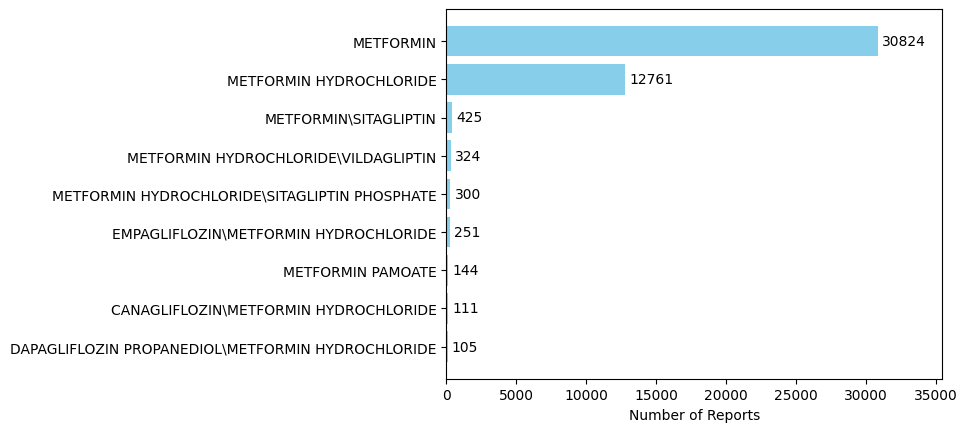

In [4]:
import matplotlib.pyplot as plt

drug_counts = Metformin_query_report_numbers.sort_values("report_count", ascending=True)

plt.barh(drug_counts["drugname"], drug_counts["report_count"], color="skyblue")

bars = plt.barh(drug_counts["drugname"], drug_counts["report_count"], color="skyblue")
plt.bar_label(bars, padding=3)
plt.xlim(0, drug_counts["report_count"].max() * 1.15)

plt.xlabel("Number of Reports")

In [5]:
#sql query to join drug and reaction tables to analyze the most common adverse events associated with Metformin, ensuring we capture all relevant reports by including all name variations of Metformin.

Metformin_reactions_joined = pd.read_sql_query("""
                            SELECT
                            d.drugname,
                            r.pt AS reaction,
                            COUNT(*) AS report_count
FROM drug d
JOIN reac r ON d.primaryid = r.primaryid
WHERE d.drugname LIKE '%METFORMIN%'
GROUP BY d.drugname, r.pt
HAVING COUNT(*) >= 50
ORDER BY report_count DESC;
                            """, conn)

Metformin_reactions_joined


,drugname,reaction,report_count
0,METFORMIN,Diarrhoea,3925
1,METFORMIN,Fatigue,3871
2,METFORMIN,Off label use,3755
3,METFORMIN,Nausea,3631
4,METFORMIN,Dyspnoea,3409
...,...,...,...
1366,METFORMIN HYDROCHLORIDE,Device issue,50
1367,METFORMIN HYDROCHLORIDE,Neuralgia,50
1368,METFORMIN HYDROCHLORIDE,Potentiating drug interaction,50
1369,METFORMIN HYDROCHLORIDE,Respiratory disorder,50


In [8]:
reactions_for_metformin_combos = pd.read_sql_query(r"""
SELECT
    r.pt AS symptom,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'METFORMIN'
        THEN r.primaryid
    END) AS metformin_count,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'METFORMIN HYDROCHLORIDE'
        THEN r.primaryid
    END) AS metformin_hydrochloride_count,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'METFORMIN/SITAGLIPTIN'
        THEN r.primaryid
    END) AS metformin_sitagliptin_count,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'METFORMIN HYDROCHLORIDE/VILDAGLIPTIN'
        THEN r.primaryid
    END) AS metformin_hydrochloride_vildagliptin_count,

    COUNT(DISTINCT CASE
        WHEN d.drugname = 'METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE'
        THEN r.primaryid
    END) AS metformin_hydrochloride_sitagliptin_phosphate_count,
                                                   
    COUNT(DISTINCT CASE
        WHEN d.drugname = 'EMPAGLIFLOZIN\METFORMIN HYDROCHLORIDE'
        THEN r.primaryid
    END) AS empagliflozin_metformin_hydrochloride_count,
                                                   
    COUNT(DISTINCT CASE
        WHEN d.drugname = 'METFORMIN PAMOATE'
        THEN r.primaryid
    END) AS metformin_pamoate_count


FROM reac r
JOIN drug d
    
    ON r.primaryid = d.primaryid
WHERE d.drugname LIKE '%METFORMIN%'   

                                                   
GROUP BY r.pt 
ORDER BY metformin_count DESC;
""", conn)

reactions_for_metformin_combos.head(20)

,symptom,metformin_count,metformin_hydrochloride_count,metformin_sitagliptin_count,metformin_hydrochloride_vildagliptin_count,metformin_hydrochloride_sitagliptin_phosphate_count,empagliflozin_metformin_hydrochloride_count,metformin_pamoate_count
0,Diarrhoea,1910,686,0,0,22,6,8
1,Nausea,1853,686,0,0,15,5,0
2,Off label use,1819,545,0,0,12,9,4
3,Fatigue,1734,761,0,0,14,7,2
4,Lactic acidosis,1417,497,0,0,2,17,3
5,Drug ineffective,1393,410,0,0,7,4,2
6,Acute kidney injury,1325,351,0,0,3,24,13
7,Vomiting,1198,408,0,0,18,6,0
8,Pain,1135,504,0,0,19,1,1
9,Dyspnoea,1123,716,0,0,6,6,1


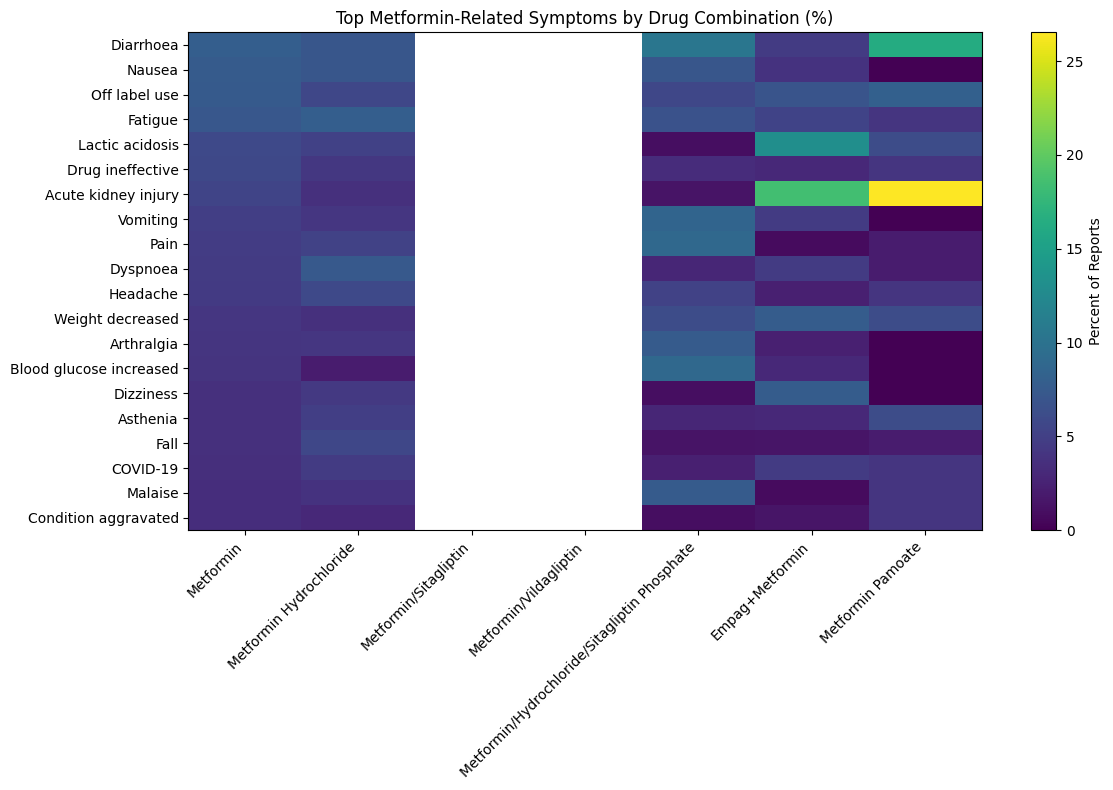

In [19]:
# Diarrhoea: Frequent loose or watery stools
# Off label use: Drug used outside its approved indication
# Neutropenia: Low neutrophil count (increased infection risk)
# Nausea: Sensation of needing to vomit
# Neuropathy peripheral: Nerve damage causing numbness/tingling in hands or feet
# Drug ineffective: Treatment did not produce intended effect
# Disease progression: Worsening or advancement of disease
# Vomiting: Forceful expulsion of stomach contents
# Thrombocytopenia: Low platelet count (increased bleeding risk)
# Fatigue: Extreme tiredness or lack of energy
# Malignant neoplasm progression: Cancer growth or spread
# Myelosuppression: Reduced bone marrow activity (fewer blood cells produced)
# Anaemia: Low red blood cell count or hemoglobin
# Decreased appetite: Reduced desire to eat
# Pyrexia: Fever
# Febrile neutropenia: Fever with low neutrophils (serious condition)
# Asthenia: General physical weakness
# Product use in unapproved indication: Drug used for a non-approved condition
# Acute kidney injury: Sudden decline in kidney function
# Rash: Skin irritation or eruption
#


import matplotlib.pyplot as plt

# Rename columns to shorter labels for plotting
plot_df = reactions_for_metformin_combos.rename(columns={
    "metformin_count": "Metformin",
    "metformin_hydrochloride_count": "Metformin Hydrochloride",
    "metformin_sitagliptin_count": "Metformin/Sitagliptin",
    "metformin_hydrochloride_vildagliptin_count": "Metformin/Vildagliptin",
    "metformin_hydrochloride_sitagliptin_phosphate_count": "Metformin/Hydrochloride/Sitagliptin Phosphate",
    "empagliflozin_metformin_hydrochloride_count": "Empag+Metformin",
    "metformin_pamoate_count": "Metformin Pamoate"
})

# Set symptom as index
heatmap_df = plot_df.set_index("symptom")

# Keep top 20 symptoms based on the original ordering
heatmap_df = heatmap_df.head(20)

# Normalize each column independently to percentages
heatmap_pct = heatmap_df.div(heatmap_df.sum(axis=0), axis=1) * 100

plt.figure(figsize=(12, 8))
plt.imshow(heatmap_pct, aspect="auto")
plt.colorbar(label="Percent of Reports")

plt.xticks(
    range(len(heatmap_pct.columns)),
    heatmap_pct.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(heatmap_pct.index)),
    heatmap_pct.index
)

plt.title("Top Metformin-Related Symptoms by Drug Combination (%)")
plt.tight_layout()
plt.show()  

In [16]:
check_for_reac_metformin = pd.read_sql_query(r"""
SELECT
    d.drugname,
    COUNT(DISTINCT d.primaryid) AS report_count,
    COUNT(r.pt) AS reaction_rows
FROM drug d
LEFT JOIN reac r
    ON d.primaryid = r.primaryid
WHERE d.drugname IN (
    'METFORMIN\SITAGLIPTIN',
    'METFORMIN HYDROCHLORIDE\VILDAGLIPTIN',
    'METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE'
)
GROUP BY d.drugname
ORDER BY report_count DESC;
""", conn)

check_for_reac_metformin

,drugname,report_count,reaction_rows
0,METFORMIN\SITAGLIPTIN,280,3391
1,METFORMIN HYDROCHLORIDE\VILDAGLIPTIN,247,1908
2,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,156,3919


In [15]:
check_specific = pd.read_sql_query("""
SELECT drugname, COUNT(*) AS count
FROM drug
WHERE drugname LIKE '%SITAGLIPTIN%'
   OR drugname LIKE '%VILDAGLIPTIN%'
GROUP BY drugname
ORDER BY count DESC;
""", conn)

check_specific

,drugname,count
0,SITAGLIPTIN,1899
1,VILDAGLIPTIN,709
2,SITAGLIPTIN PHOSPHATE,537
3,METFORMIN\SITAGLIPTIN,425
4,METFORMIN HYDROCHLORIDE\VILDAGLIPTIN,324
5,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,300
6,METFORMIN\VILDAGLIPTIN,56
7,IPRAGLIFLOZIN L-PROLINE\SITAGLIPTIN PHOSPHATE,43
8,METFORMIN HYDROCHLORIDE\SITAGLIPTIN,30
9,VILDAGLIPTIN / METFORMIN TEVA,5


In [17]:
check_for_reac_metformin = pd.read_sql_query(r"""
SELECT
    d.drugname,
    COUNT(DISTINCT d.primaryid) AS report_count,
    COUNT(r.pt) AS reaction_rows
FROM drug d
LEFT JOIN reac r
    ON d.primaryid = r.primaryid
WHERE d.drugname IN (
    'METFORMIN\SITAGLIPTIN',
    'METFORMIN HYDROCHLORIDE\VILDAGLIPTIN',
    'METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE'
)
GROUP BY d.drugname
ORDER BY report_count DESC;
""", conn)

check_for_reac_metformin

,drugname,report_count,reaction_rows
0,METFORMIN\SITAGLIPTIN,280,3391
1,METFORMIN HYDROCHLORIDE\VILDAGLIPTIN,247,1908
2,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,156,3919


In [18]:
combo_reactions = pd.read_sql_query(r"""
SELECT
    d.drugname,
    r.pt AS reaction,
    COUNT(DISTINCT d.primaryid) AS report_count
FROM drug d
JOIN reac r
    ON d.primaryid = r.primaryid
WHERE d.drugname IN (
    'METFORMIN\SITAGLIPTIN',
    'METFORMIN HYDROCHLORIDE\VILDAGLIPTIN',
    'METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE'
)
GROUP BY d.drugname, r.pt
ORDER BY d.drugname, report_count DESC;
""", conn)

combo_reactions.head(20)

,drugname,reaction,report_count
0,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,Blood pressure increased,26
1,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,Type 2 diabetes mellitus,24
2,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,Pneumonia,23
3,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,Hyperglycaemia,23
4,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,Gastrooesophageal reflux disease,23
5,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,Diarrhoea,22
6,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,Asthma,20
7,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,Pain in extremity,19
8,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,Pain,19
9,METFORMIN HYDROCHLORIDE\SITAGLIPTIN PHOSPHATE,Full blood count abnormal,19
